<a href="https://colab.research.google.com/github/BuddhikaRoshan/HemoAi/blob/main/IT22564122_Latest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install seaborn opencv-python scikit-learn lime -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
source_dir = "/content/drive/MyDrive/dataset"
output_dir = "/content/drive/MyDrive/final_dataset2"

classes = ['ALL','AML','CLL','CML','Healthy']

for cls in classes:
    files = [f for f in os.listdir(os.path.join(source_dir, cls))
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

    random.shuffle(files)
    n = len(files)

    train_end = int(n*0.7)
    val_end = int(n*0.85)

    splits = {
        "train": files[:train_end],
        "val": files[train_end:val_end],
        "test": files[val_end:]
    }

    for split, file_list in splits.items():
        for f in file_list:
            src = os.path.join(source_dir, cls, f)
            dst = os.path.join(output_dir, split, cls, f)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)

print("Dataset split done")

Dataset split done


In [ ]:
def stain_normalization(img):
    # Convert input image to uint8 type for OpenCV functions
    # Assuming input 'img' is float32 with values in [0, 255]
    img_uint8 = img.astype(np.uint8)

    # Convert to LAB color space
    img_lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    # Split LAB channels
    l, a, b = cv2.split(img_lab)
    # Apply histogram equalization to the L channel (which is now uint8)
    l = cv2.equalizeHist(l)
    # Merge channels back
    img_merged = cv2.merge((l, a, b))
    # Convert back to RGB
    return cv2.cvtColor(img_merged, cv2.COLOR_LAB2RGB)

def preprocess(img):
    img = stain_normalization(img)
    return img / 255.0

In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=40,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess)

train_data = train_gen.flow_from_directory(output_dir+"/train", target_size=(224,224), batch_size=32, class_mode='categorical')
val_data   = val_gen.flow_from_directory(output_dir+"/val", target_size=(224,224), batch_size=32, class_mode='categorical')
test_data  = val_gen.flow_from_directory(output_dir+"/test", target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)

class_labels = list(train_data.class_indices.keys())
NUM_CLASSES = len(class_labels)

Found 3500 images belonging to 5 classes.
Found 750 images belonging to 5 classes.
Found 750 images belonging to 5 classes.


In [ ]:
def cbam_block(x):
    ch = x.shape[-1]
    avg = layers.GlobalAveragePooling2D()(x)
    avg = layers.Reshape((1,1,ch))(avg)
    att = layers.Dense(ch, activation='sigmoid')(avg)
    return layers.Multiply()([x, att])

In [ ]:
def build_model():
    inp = layers.Input(shape=(224,224,3))

    densenet = DenseNet121(weights='imagenet', include_top=False, input_tensor=inp)
    mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)

    # FREEZE BASE MODELS
    for layer in densenet.layers:
        layer.trainable = False
    for layer in mobilenet.layers:
        layer.trainable = False

    d_out = layers.GlobalAveragePooling2D()(densenet.output)
    m_out = layers.GlobalAveragePooling2D()(mobilenet.output)

    merged = layers.Concatenate()([d_out, m_out])

    x = layers.Reshape((1,1,merged.shape[-1]))(merged)
    x = cbam_block(x)
    x = layers.Flatten()(x)

    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inp, out)

model = build_model()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipykernel_29123/2960867885.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def focal_loss(gamma=2., alpha=.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1-y_pred, gamma)
        return tf.reduce_mean(weight * ce)
    return loss

y_train = train_data.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss(),
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(patience=3),
        ModelCheckpoint("best_model.h5", save_best_only=True)
    ]
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4569 - loss: 0.0537

110/110 ━━━━━━━━━━━━━━━━━━━━ 1300s 12s/step - accuracy: 0.5846 - loss: 0.0379 - val_accuracy: 0.7827 - val_loss: 0.0129 - learning_rate: 1.0000e-04
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7374 - loss: 0.0218

110/110 ━━━━━━━━━━━━━━━━━━━━ 1307s 12s/step - accuracy: 0.7380 - loss: 0.0206 - val_accuracy: 0.8333 - val_loss: 0.0091 - learning_rate: 1.0000e-04
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7674 - loss: 0.0158

110/110 ━━━━━━━━━━━━━━━━━━━━ 1237s 11s/step - accuracy: 0.7831 - loss: 0.0146 - val_accuracy: 0.8587 - val_loss: 0.0085 - learning_rate: 1.0000e-04
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7916 - loss: 0.0141

110/110 ━━━━━━━━━━━━━━━━━━━━ 1255s 11s/step - accuracy: 0.8097 - loss: 0.0124 - val_accuracy: 0.8573 - val_loss: 0.0079 - learning_rate: 1.0000e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8287 - loss: 0.0111

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 1260s 11s/step - accuracy: 0.8743 - loss: 0.0068 - val_accuracy: 0.9053 - val_loss: 0.0046 - learning_rate: 1.0000e-04
Epoch 12/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8754 - loss: 0.0069

110/110 ━━━━━━━━━━━━━━━━━━━━ 1210s 11s/step - accuracy: 0.8797 - loss: 0.0069 - val_accuracy: 0.9040 - val_loss: 0.0046 - learning_rate: 1.0000e-04
Epoch 13/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1214s 11s/step - accuracy: 0.8849 - loss: 0.0064 - val_accuracy: 0.9000 - val_loss: 0.0047 - learning_rate: 1.0000e-04
Epoch 14/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8832 - loss: 0.0064

110/110 ━━━━━━━━━━━━━━━━━━━━ 1221s 11s/step - accuracy: 0.8917 - loss: 0.0061 - val_accuracy: 0.9107 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 15/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8962 - loss: 0.0059

110/110 ━━━━━━━━━━━━━━━━━━━━ 1220s 11s/step - accuracy: 0.8889 - loss: 0.0061 - val_accuracy: 0.9080 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 16/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1205s 11s/step - accuracy: 0.9006 - loss: 0.0057 - val_accuracy: 0.9027 - val_loss: 0.0043 - learning_rate: 1.0000e-04
Epoch 17/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9130 - loss: 0.0050

110/110 ━━━━━━━━━━━━━━━━━━━━ 1219s 11s/step - accuracy: 0.9063 - loss: 0.0054 - val_accuracy: 0.9160 - val_loss: 0.0037 - learning_rate: 1.0000e-04
Epoch 18/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1226s 11s/step - accuracy: 0.9051 - loss: 0.0054 - val_accuracy: 0.9200 - val_loss: 0.0040 - learning_rate: 1.0000e-04
Epoch 19/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1202s 11s/step - accuracy: 0.9126 - loss: 0.0052 - val_accuracy: 0.9120 - val_loss: 0.0038 - learning_rate: 1.0000e-04
Epoch 20/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1204s 11s/step - accuracy: 0.9069 - loss: 0.0049 - val_accuracy: 0.9213 - val_loss: 0.0039 - learning_rate: 1.0000e-04


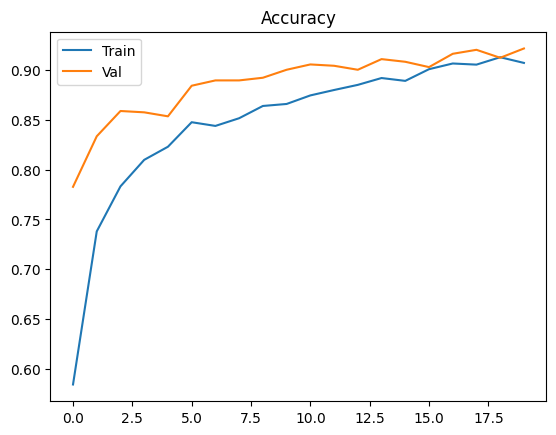

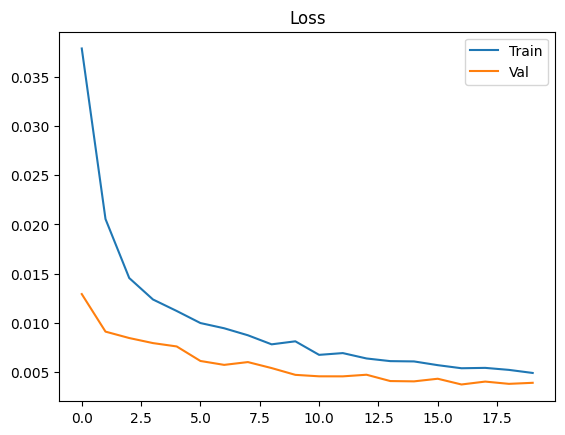

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Val'])
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 212s 8s/step


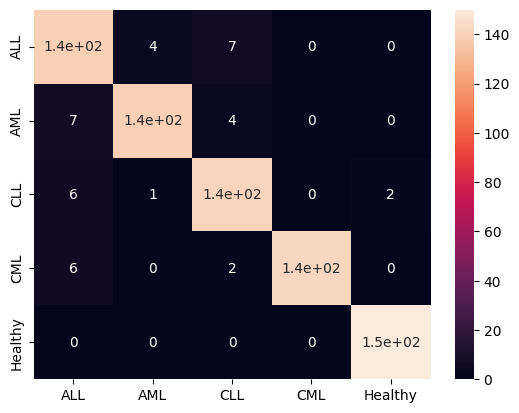

              precision    recall  f1-score   support

         ALL       0.88      0.93      0.90       150
         AML       0.97      0.93      0.95       150
         CLL       0.92      0.94      0.93       150
         CML       1.00      0.95      0.97       150
     Healthy       0.99      1.00      0.99       150

    accuracy                           0.95       750
   macro avg       0.95      0.95      0.95       750
weighted avg       0.95      0.95      0.95       750



In [ ]:
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True,
            xticklabels=class_labels, yticklabels=class_labels)
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


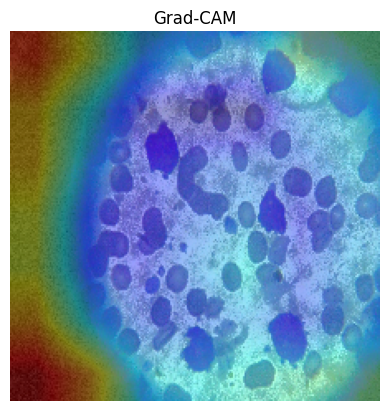

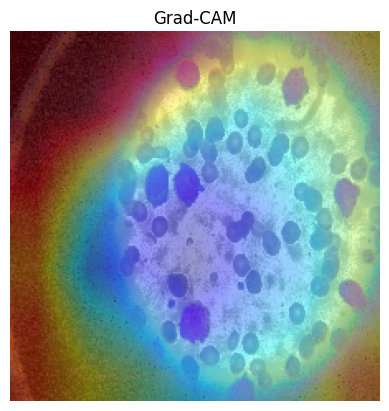

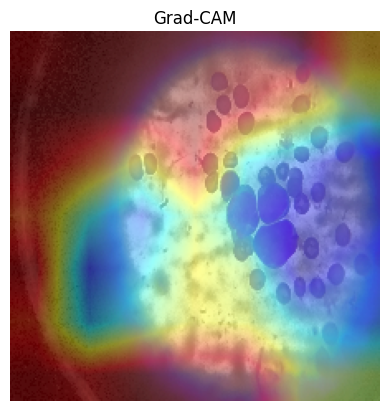

In [ ]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

last_conv = get_last_conv_layer(model)

def gradcam(img):
    img = np.expand_dims(img, axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        loss = preds[:, np.argmax(preds[0])]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap

# show multiple samples
for i in range(3):
    img, _ = test_data[i]
    image = img[0]

    heatmap = gradcam(image)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(np.uint8(image*255), 0.6, heatmap, 0.4, 0)

    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2

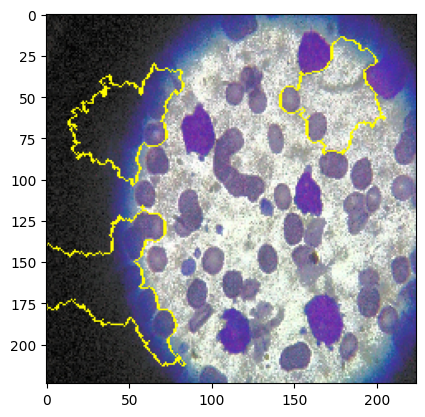

In [ ]:
explainer = lime_image.LimeImageExplainer()

img_batch, _ = test_data[0]
image = img_batch[0]

explanation = explainer.explain_instance(
    image,
    lambda x: model.predict(x),
    top_labels=3,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0])
plt.imshow(mark_boundaries(temp, mask))
plt.show()

In [ ]:
# Save in HDF5 (legacy but widely supported)
model.save("/content/drive/MyDrive/leukemia_New_model.h5")

# Save in Keras native format (RECOMMENDED)
model.save("/content/drive/MyDrive/leukemia__New_model.keras")

# Convert to TensorFlow Lite (for deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/drive/MyDrive/leukemia__New_model.tflite", "wb") as f:
    f.write(tflite_model)

print("All models saved successfully!")

Saved artifact at '/tmp/tmpv6d3g_gh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140439327030736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324233360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324231824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324232592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324232976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324232016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324233744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439327030544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324232784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140439324235088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14043932424334